# Linear wave theory
__In this notebook__:
* I'm playing around with linear wave theory and looking into the effects of depth on velocity
* In my lab experiments, I want the waves to be such that they have a noticeable velocity close to the bottom. This is because if we want to dampen the waves, the waves need to feel the bottom to be impacted by it. Aka some energy has to be down there for it to be damped.
* Goal is to see that for longer waves, there are more energy at the bottom.
* I want to plot the horizontal velcoty with depth for a given x and t.

### Basics
* Irrotational fluid, $\nabla \times \boldsymbol{u} = 0$
* Can be described by a velocity potential, $\boldsymbol{u} = \nabla \phi$
* Incompressible fluid, $\nabla \cdot \boldsymbol{u} = \nabla ^2 \phi = 0$
* Pressure at the free surface equals atmospheric pressure, $p_0 = P_{atmos}$
* Impermeable bottom, $\boldsymbol{u} \cdot \boldsymbol{n} = 0$

* The wavelength is $\lambda = \frac{2 \pi}{k}$
* Wave period is $T = \frac{2 \pi}{\omega}$
* Frequency is $f = \frac{1}{T}$
* Angular frequency $\omega = 2\pi f$
* Phase speed, $c = \frac{\omega}{k}$

### Wave equations - linear theory, arbitrary depth
* Surface elevation can be described as, $\eta = asin(kx -\omega t)$
* The velcoity potential can be written as, $\phi = -\frac{a \omega}{k sinh(kH)}cosh(k(z+H))cos(kx - \omega t)$
* The dispersion relation, $\omega ^2 = (gk + \frac{\sigma k^3}{\rho})tanh(kH)$. I will ignore surface tension and put $\sigma = 0$.
* Wave speed, $c = c_0(1 + \frac{\sigma k^2}{\rho g})^{1/2} (\frac{tanh(kH)}{kH})^{1/2}$
* Shallow water wave speed, $c_0 = \sqrt{gH}$

### Dimensionless groups

In linear wave theory, thw two important dimensionless groups are:
* Relative depth, $kH$, which determines the regime (shallow, intermediate, deep)
* Wave steepness, $ak$, which measures nonlinearity (small for linear waves).

In the wave tank, I will measure the damping due to a "porous bottom", or more precisely due to 35 vertical walls at the bottom (Hele-Shaw cells). I want to quantify the effect these walls have on the waves due to viscous boundary layers within the cells. The degree of "porosity" or damping will be changed by changing the water depth in the tank. This is because I have 35 plates which are of fixed heights, so by changing the water depth, the relative portion of the water column which is "porous" will be larger for smalle water depths, and hopefully show more damping. 

But, to be able to compare these runs with different water depths to one another, the waves need to be the same but scaled. Therefore, the dimensionless parameters of relative depth and wave steepness need to be held constant. 

In [153]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

Trying to figure out the wave maker configurations by keeping the parameters constant

In [173]:
kh_target = 0.20
ak_target = 0.05

H = [0.2, 0.3, 0.4]

k_02 = kh_target/H[0]
k_03 = kh_target/H[1]
k_04 = kh_target/H[2]

print(f'Wave number, k,  for H=0.2 m must be smaller than {k_02} [m^-1]')
print(f'Wave number, k,  for H=0.3 m must be smaller than {k_03} [m^-1]')
print(f'Wave number, k,  for H=0.4 m must be smaller than {k_04} [m^-1]')

Wave number, k,  for H=0.2 m must be smaller than 1.0 [m^-1]
Wave number, k,  for H=0.3 m must be smaller than 0.6666666666666667 [m^-1]
Wave number, k,  for H=0.4 m must be smaller than 0.5 [m^-1]


In [174]:
a_02 = ak_target/k_02
a_03 = ak_target/k_03
a_04 = ak_target/k_04

print(f'Amplitude, a,  for H=0.2 m must be smaller than {a_02} [m]')
print(f'Amplitude, a,  for H=0.3 m must be smaller than {a_03} [m]')
print(f'Amplitude, a,  for H=0.4 m must be smaller than {a_04} [m]')

Amplitude, a,  for H=0.2 m must be smaller than 0.05 [m]
Amplitude, a,  for H=0.3 m must be smaller than 0.075 [m]
Amplitude, a,  for H=0.4 m must be smaller than 0.1 [m]


In [165]:
# Inputs

a = 0.15  # amplitude [m]
f = 0.5  # frequency [1/s]
H = 0.2  # water depth [m]
x = 5.0 # position [m]
t = 3.0  # time [s]

In [166]:
g = 9.81  # gravity [m/s^2]
T = 1/f  # wave period [s]
omega = 2*np.pi*f  # angular frequency [rad/s]

In [155]:
def dispersion_relation(k):
    return omega**2 - g*k*np.tanh(k*H)

In [156]:
k_first_guess = 0.1
k = fsolve(dispersion_relation, k_first_guess)

In [157]:
print(f'Wavelength:{2*np.pi/k} m')

Wavelength:[2.70721817] m


The horizontal velocity is $u = \frac{\partial \phi}{\partial x}$, 

$$\frac{\partial \phi}{\partial x} = \frac{\partial}{\partial x}  (-\frac{a \omega}{k sinh(kH)}cosh(k(z+H))cos(kx - \omega t))$$
$$= \frac{a \omega}{sinh(kH)}cosh(k(z+H))sin(kx - \omega t))$$

In [ ]:
def horizontal_velocity(z):
    return (a*omega/np.sinh(k*H))*np.cosh(k*(z+H))*np.sin(k*x - omega*t)

In [159]:
depths = np.linspace(-H, 0, 20)
depths = np.flip(depths)

In [160]:
u_z = horizontal_velocity(depths)

Text(0, 0.5, 'Depth [m]')

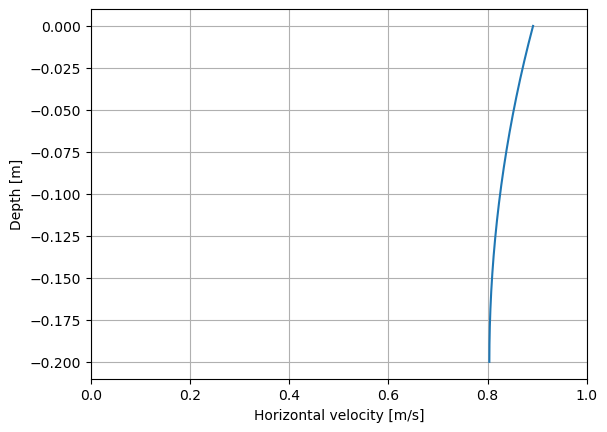

In [164]:
plt.plot(u_z, depths)
plt.grid()
plt.xlim((0, 1))

plt.xlabel('Horizontal velocity [m/s]')
plt.ylabel('Depth [m]')